# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Evita Meilinda Yudhit Nabena
- Email: evitameilinda03@gmail.com
- Id Dicoding: evitamyna

## Persiapan

### Menyiapkan library yang dibutuhkan

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

### Menyiapkan data yang akan digunakan

In [120]:
data = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/employee/employee_data.csv'
df = pd.read_csv(data)

## Data Understanding

In [121]:
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [122]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [124]:
df.isnull().sum()

,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


**Data Duplikat**

In [125]:
df.duplicated().sum()

np.int64(0)

**Insight:**
- Dataset memiliki 1.470 baris dan 35 kolom.
- **Terdapat missing values** pada Attrition sejumlah 412 baris.
- **Tidak terdapat duplikat data** pada setiap kolom.


### Data Cleaning

**Menangani Missing Values**

In [126]:
df = df.dropna(subset=['Attrition'])
df.isnull().sum()

,0
EmployeeId,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


**Menghapus Kolom yang Tidak Digunakan**

In [127]:
df=df.drop(columns=['EmployeeId', 'StandardHours', 'Over18', 'EmployeeCount'])

In [128]:
df.to_csv('employee_data_cleaned.csv', index=False)

### Exploratory Data Analysis

**Analisis Distribusi Attrition**

In [129]:
attrition_count = df['Attrition'].value_counts()
attrition_count

,count
Attrition,
0.0,879
1.0,179


In [130]:
attrition_percentage = df['Attrition'].value_counts(normalize=True) * 100
attrition_percentage

,proportion
Attrition,
0.0,83.081285
1.0,16.918715


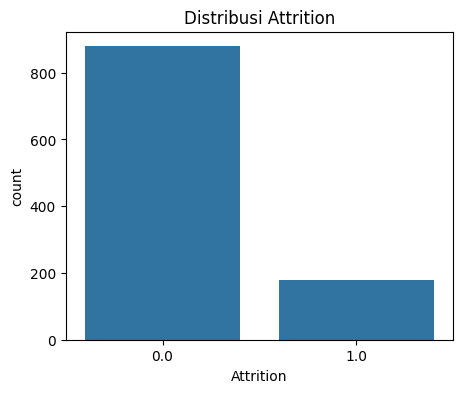

In [131]:
plt.figure(figsize=(5,4))
sns.countplot(x='Attrition', data=df)
plt.title('Distribusi Attrition')
plt.show()

**Insight:**
- 179 karyawan keluar (16,92%), hal ini tergolong tinggi
- 879 karyawan bertahan (83,1%)
- Banyaknyna karyawan yang keluar sudah cukup mengganggu stabilitas perusahaan.

**Analisis Kolom Numerik terhadap Attrition**

In [132]:
numeric_cols = list(df.select_dtypes(include='number').columns)
numeric_cols

['Age',
 'Attrition',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

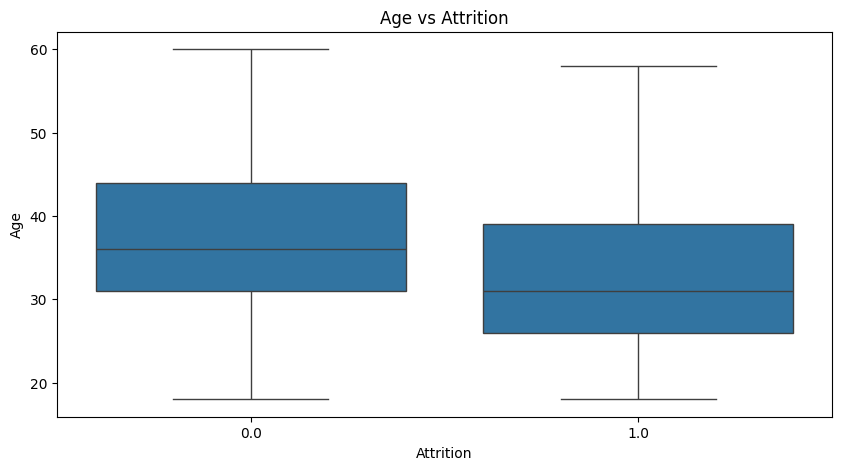

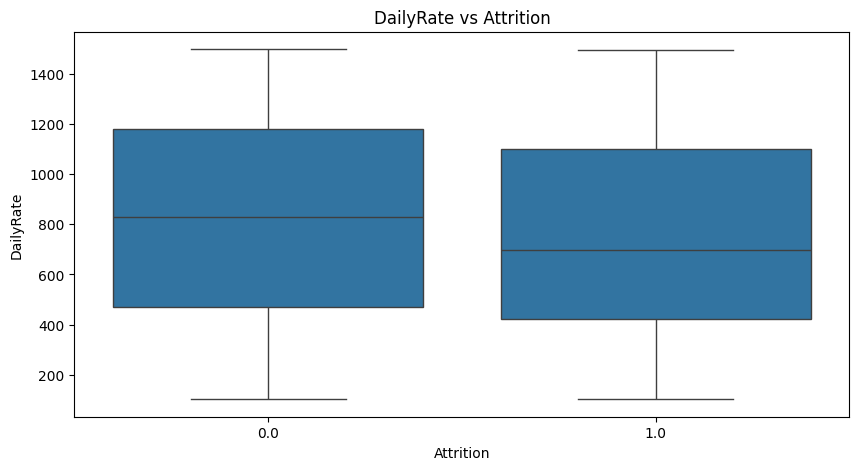

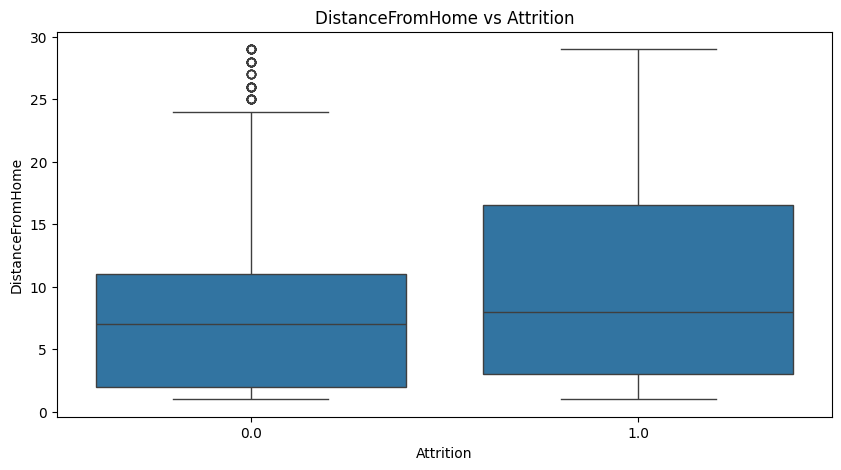

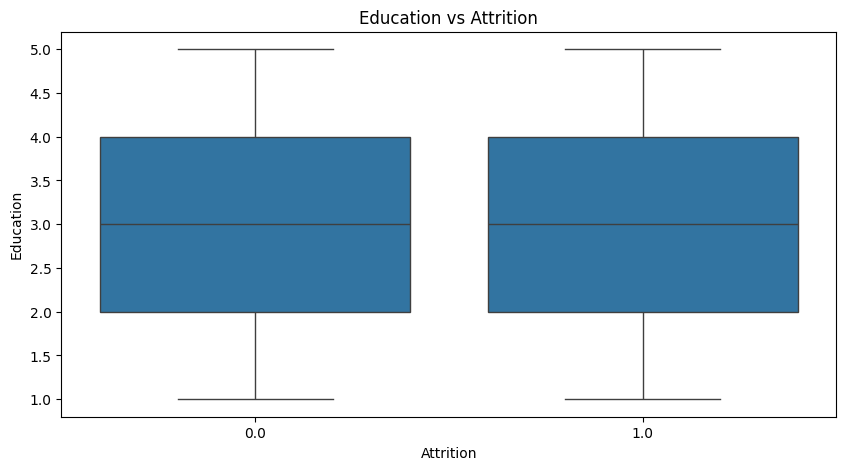

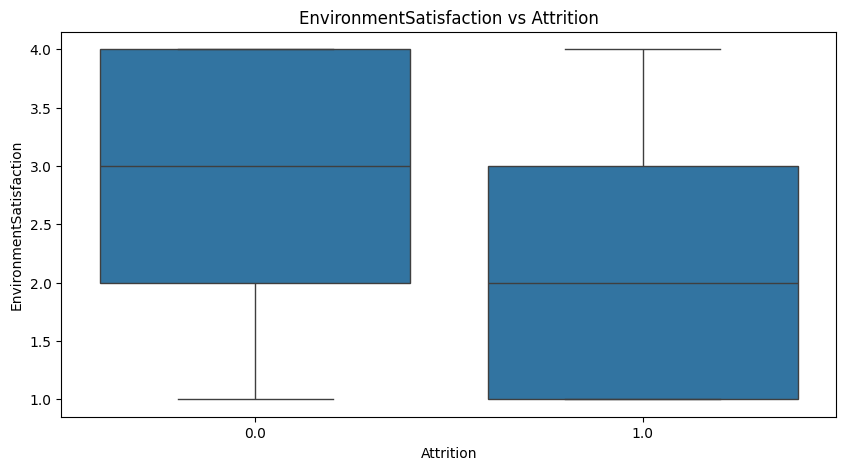

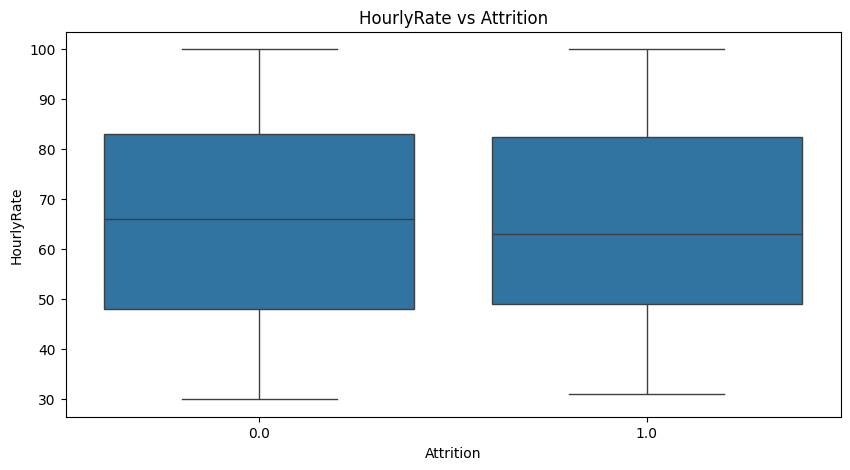

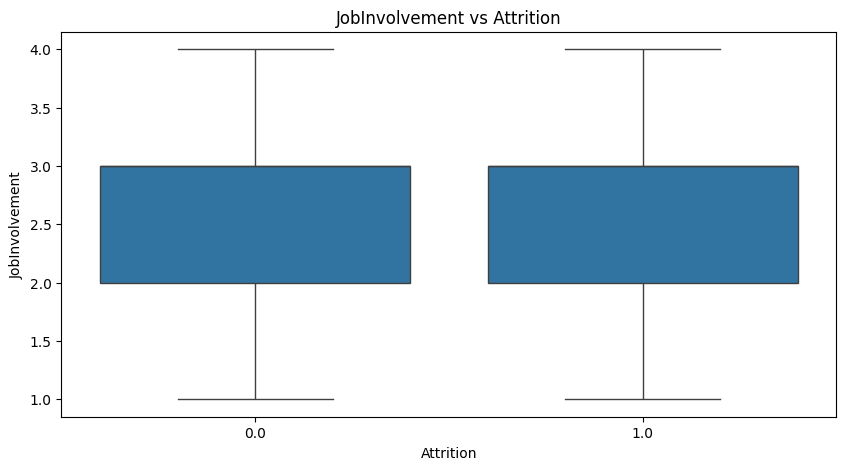

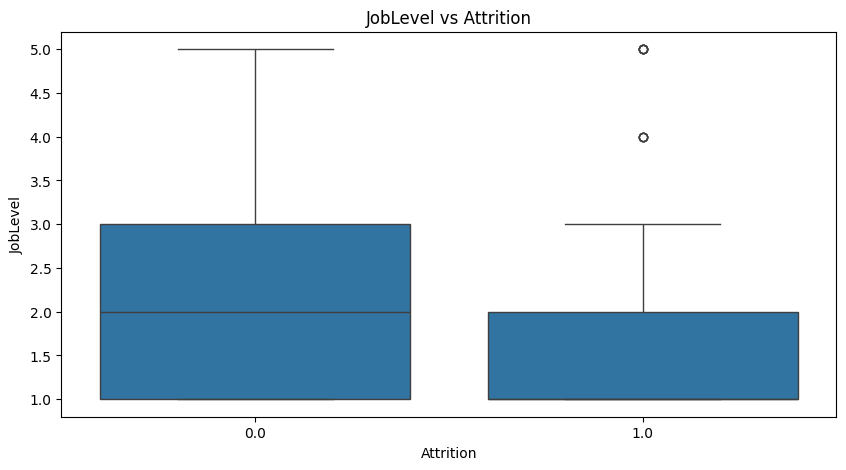

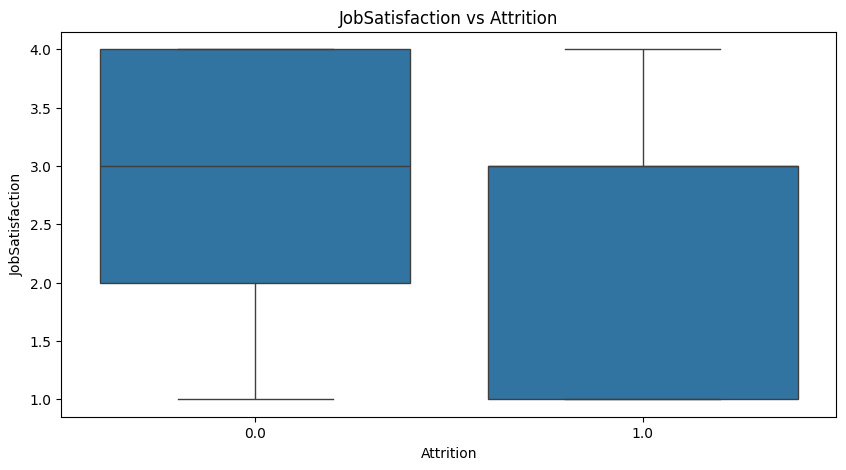

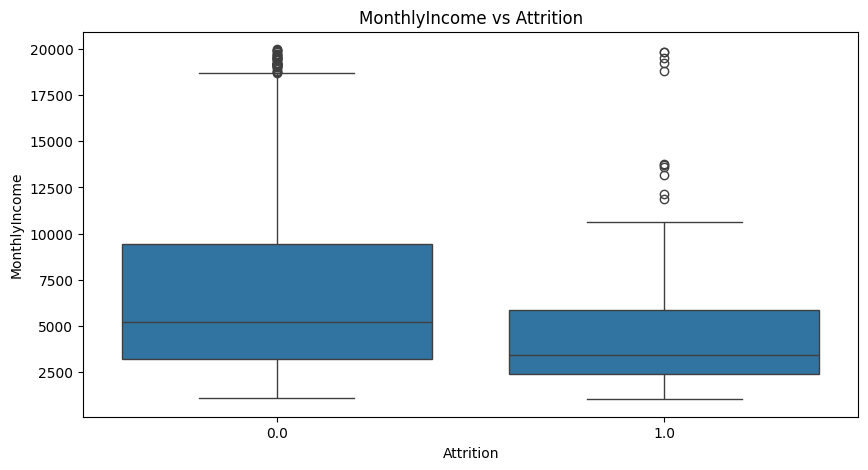

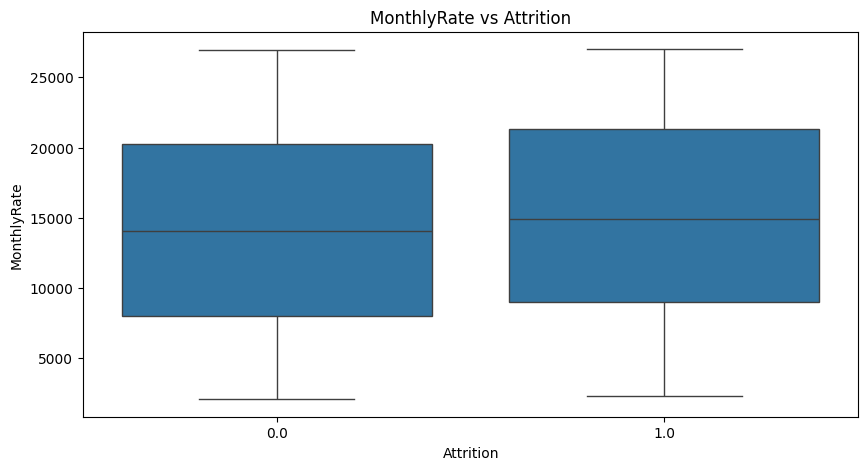

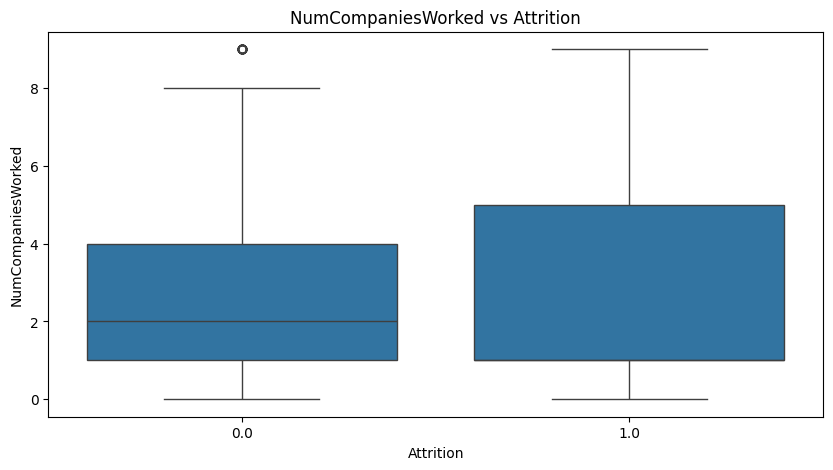

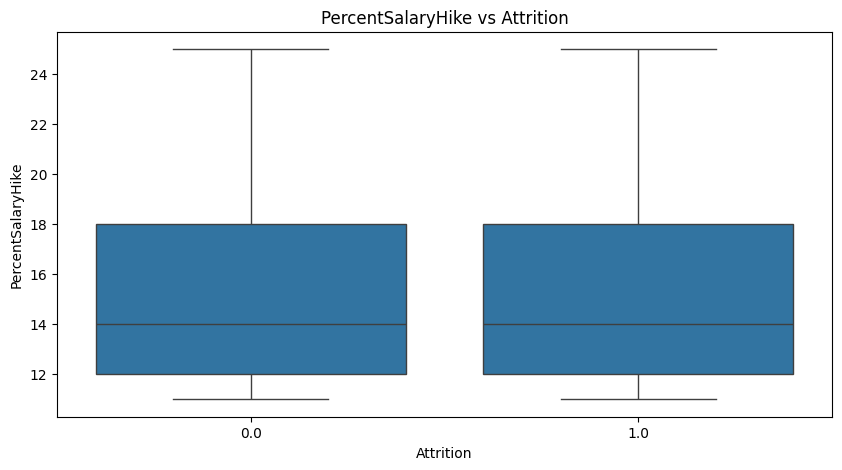

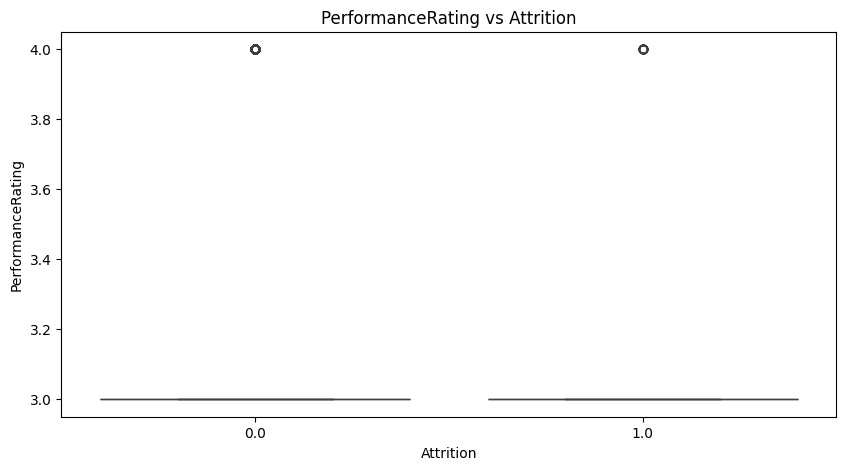

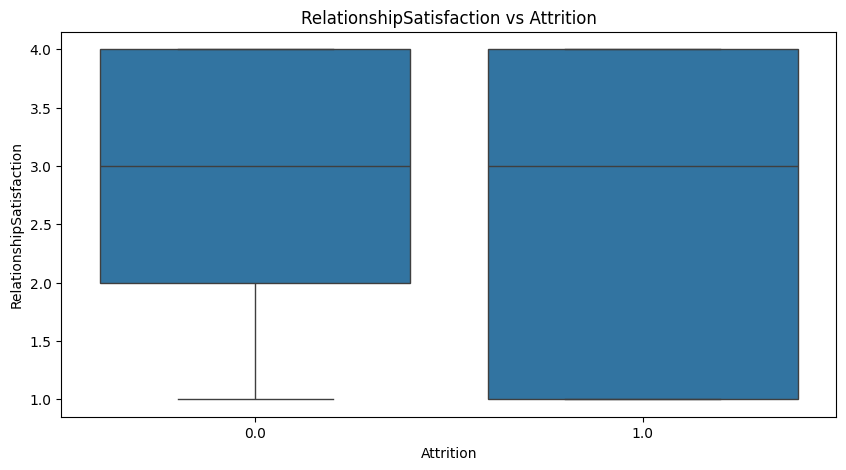

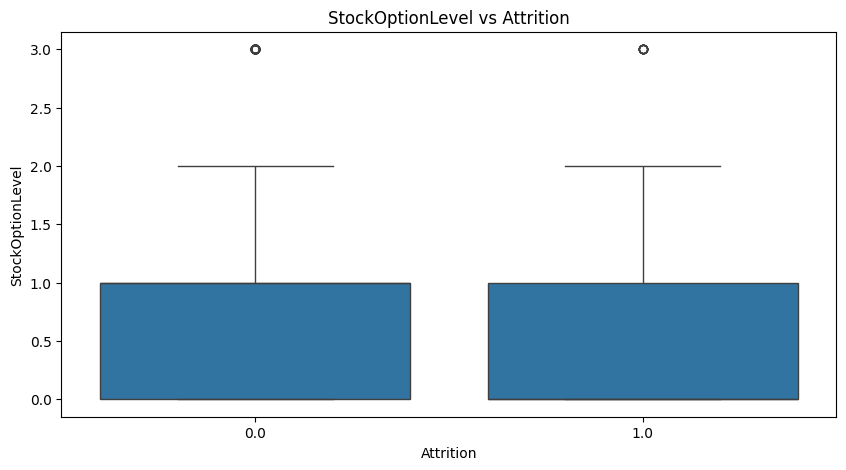

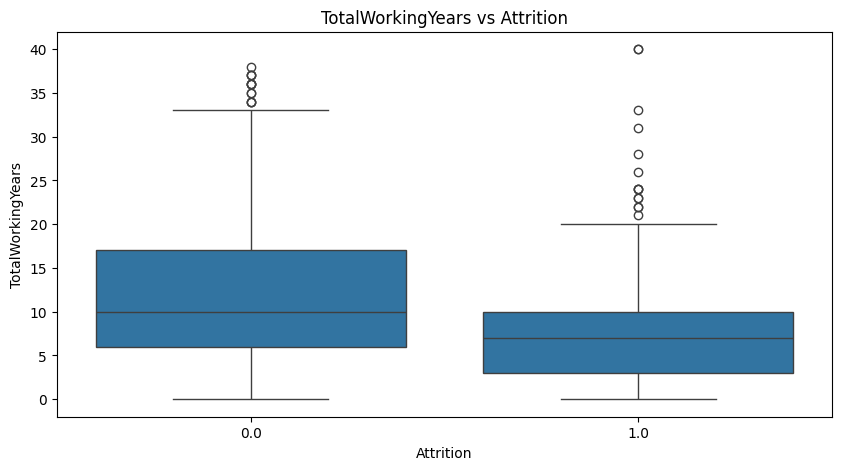

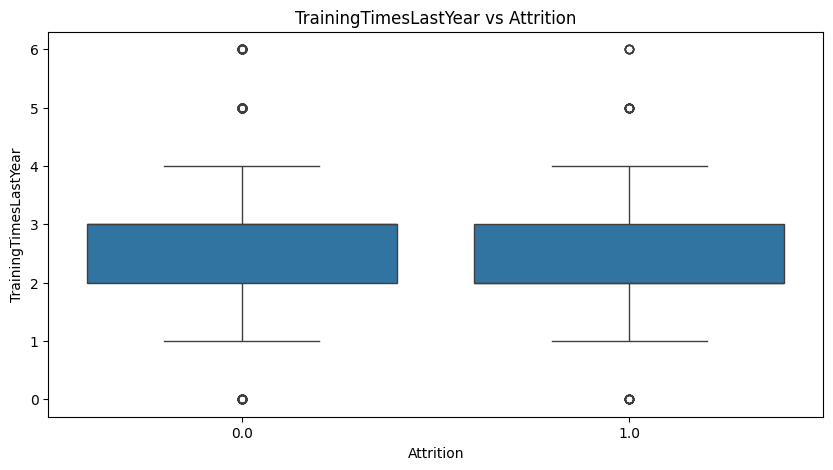

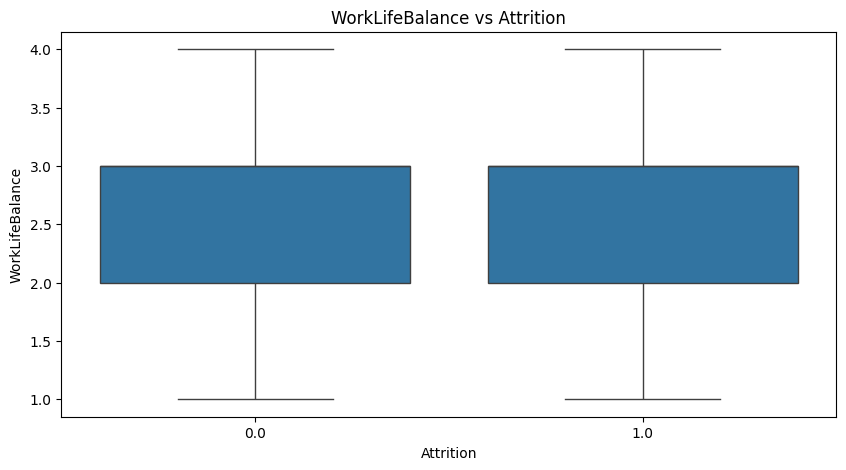

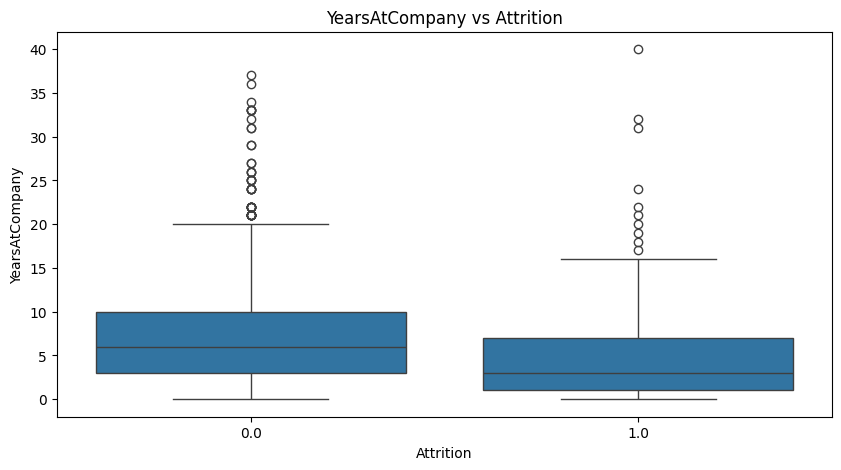

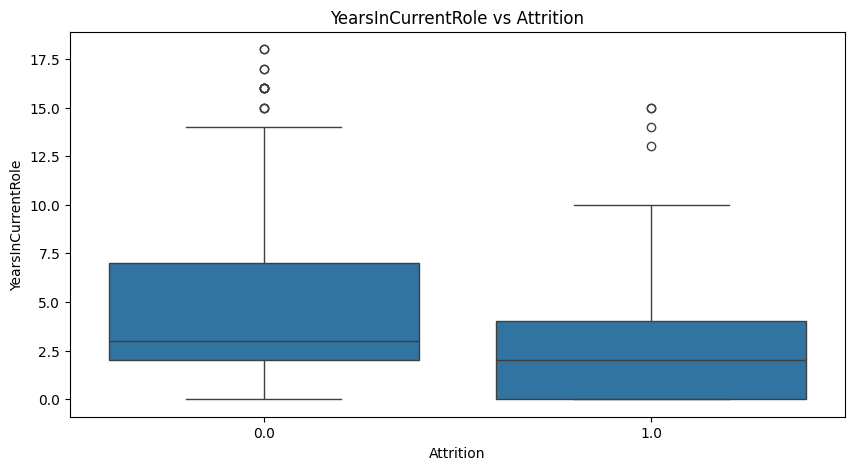

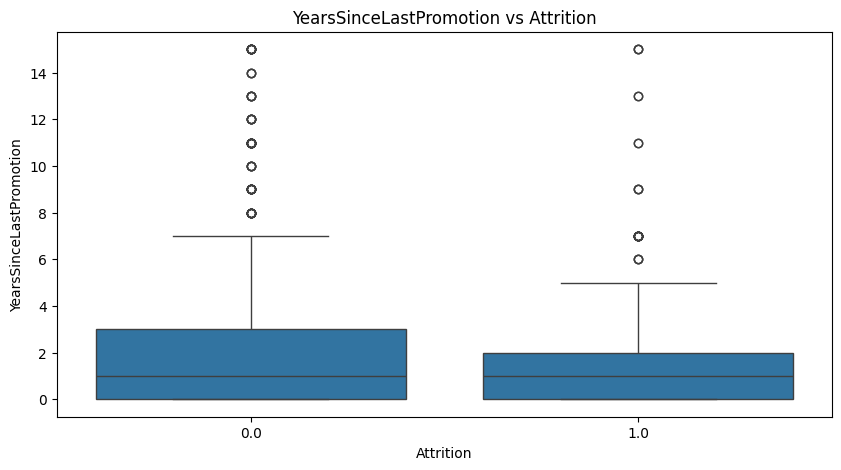

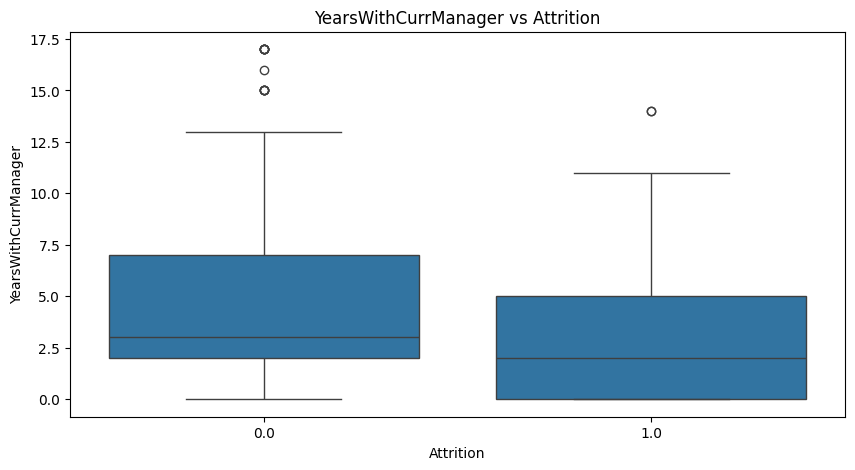

In [133]:
if 'Attrition' in numeric_cols:
    numeric_cols.remove('Attrition')

for col in numeric_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.title(f'{col} vs Attrition')
    plt.show()

**Insight:**
- Faktor dengan perbedaan signifikan

  Karyawan yang memiliki Attrition tinggi memiliki
  - Usia muda (Age)
  - Jarak kantor dengan rumah jauh (DistanceFromHome)
  - Level jabatan rendah (JobLevel)
  - MonthlyIncome  dan  StockOptionLevel yang rendah
  - MonthlyRate tinggi
  - Riwayat ssering pindah perusahaan (NumCompaniesWorked)
  - Masa kerja yang singkat, baik secara total (TotalWorkingYears), di perusahaan (YearsAtCompany), dan di posisi saat ini (YearsInCurrentRole)
  - Waktu kerja yang singkat dengan manajer saat ini (YearsWithCurrManager)
  - Kepuasan yang rendah terhadap pekerjaan (JobSatisfaction) dan lingkungan kerja (EnvironmentSatisfaction)
  - Hubungan interpersonal yang buruk di lingkungan kerja (RelationshipSatisfaction)
  - Kurangnya keseimbangan antara kehidupana pribadi dan pekerjaan (WorkLifeBalance)
- Faktor yang tidak signifikan
  - DailyRate, HourlyRate, Education, JobInvolvement, PercentSalaryHike, PerformanceRating, TrainingTimesLastYear, dan YearsSinceLastPromotion

**Analisis Kolom Kategorikal**

In [134]:
category_cols = list(df.select_dtypes(include='object').columns)
category_cols

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

<Figure size 1000x500 with 0 Axes>

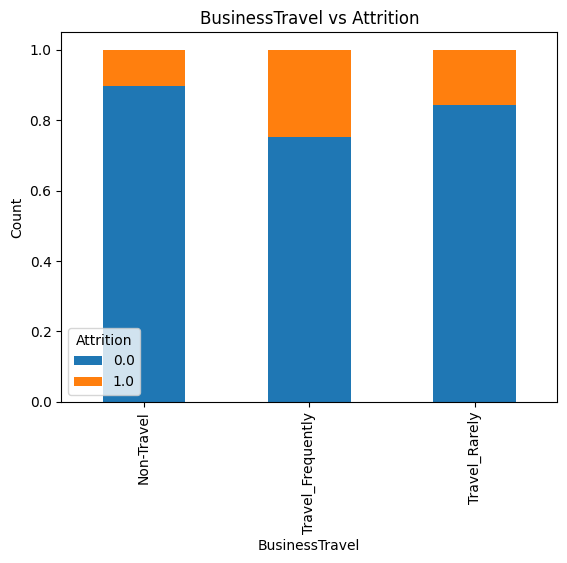

<Figure size 1000x500 with 0 Axes>

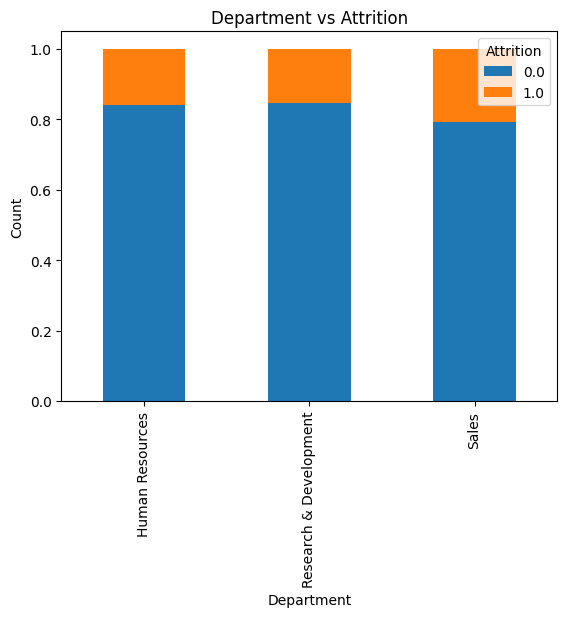

<Figure size 1000x500 with 0 Axes>

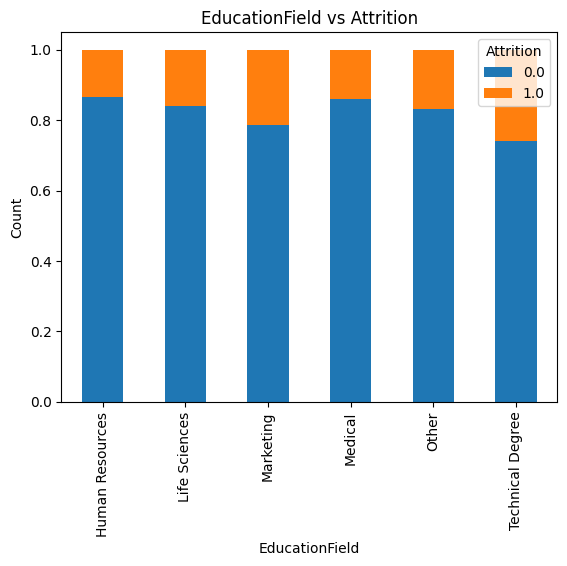

<Figure size 1000x500 with 0 Axes>

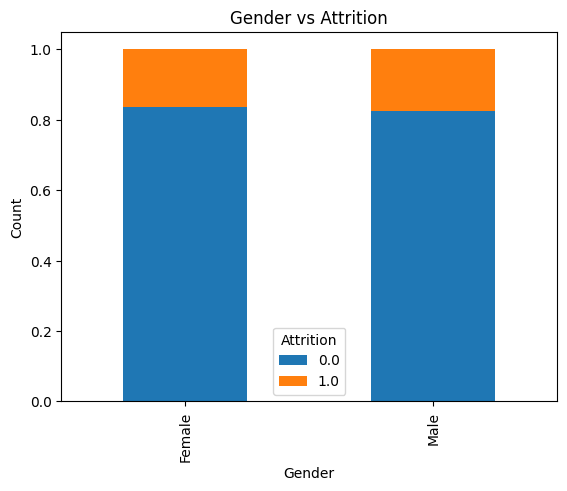

<Figure size 1000x500 with 0 Axes>

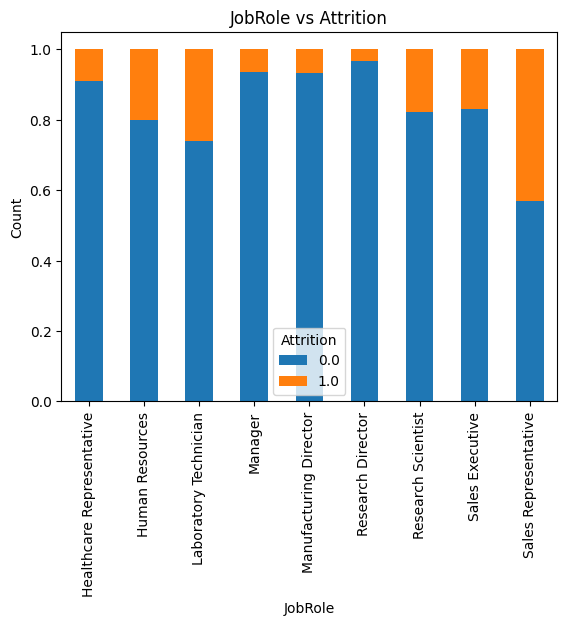

<Figure size 1000x500 with 0 Axes>

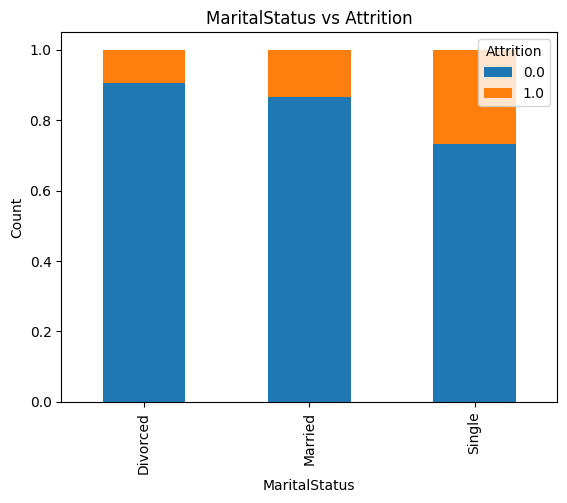

<Figure size 1000x500 with 0 Axes>

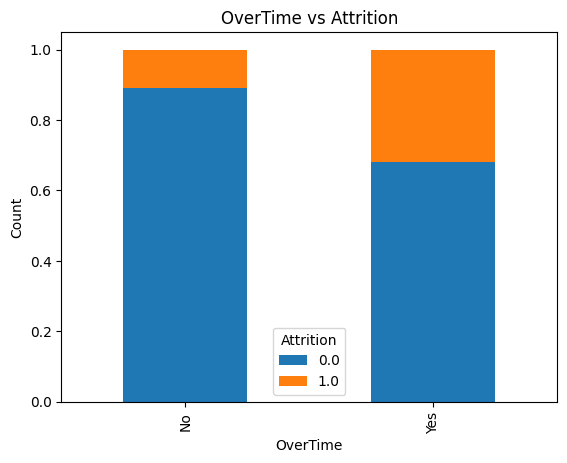

In [135]:
for col in category_cols:
  plt.figure(figsize=(10,5))
  chart = pd.crosstab(df[col], df['Attrition'])
  chart.div(chart.sum(1), axis=0).plot(kind='bar', stacked=True)
  plt.title(f'{col} vs Attrition')
  plt.xticks(rotation=90)
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.show()

**Insight:**
- Karyawan yang bekerja lembur (OverTime: Yes) dan sering melakukan perjalanan bisnis (BusinessTravel: Frquently) memiliki Attrition yang tinggi
- Departemen Sales memiliki Attrition yang tinggi
- Attrition tinggi terlihat pada Sales Representative, Laboratory Technician, dan Human Resources. Sebaliknya, Manager dan Research Director memiliki tingkat Attrition yang rendah
- Karyawan yang belum menikah (MaritalStatus: Single) memiliki Attrition yang tinggi
- Karyawan laki-laiki (Gender: Male) memiliki attrition yang lebih tinggi dibanding karyawan wanita, namun perbedaan tidak terlalu jauh.
- Bidang pendidikan Technical dan Marketing memiliki Attrition yang tinggi

In [136]:
joblevel = df.groupby('JobLevel')['Attrition'].mean().reset_index()
df.groupby('JobLevel')['Attrition'].agg(['mean','count'])

,mean,count
JobLevel,,
1,0.274112,394
2,0.101648,364
3,0.151515,165
4,0.050000,80
5,0.090909,55


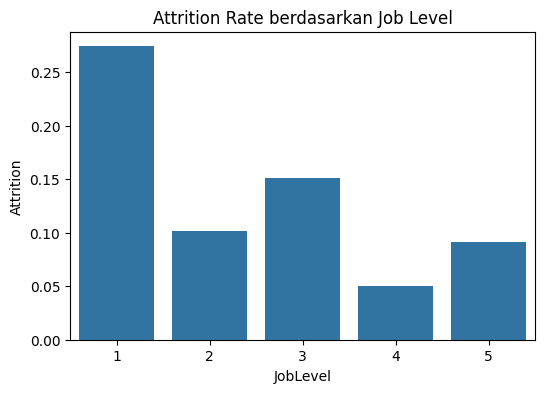

In [137]:
plt.figure(figsize=(6,4))
sns.barplot(x='JobLevel', y='Attrition', data=joblevel)
plt.title('Attrition Rate berdasarkan Job Level')
plt.show()

**Insight:**
- 394 karyawan dengan JobLevel 1 paling banyak keluar (37,2%)
- 55 karyawan dengan JobLevel 4 paling sedikit keluar (5,2%)
- Semakin tinggi job level, maka Attrition semakin rendah

**Korelasi Numerik**

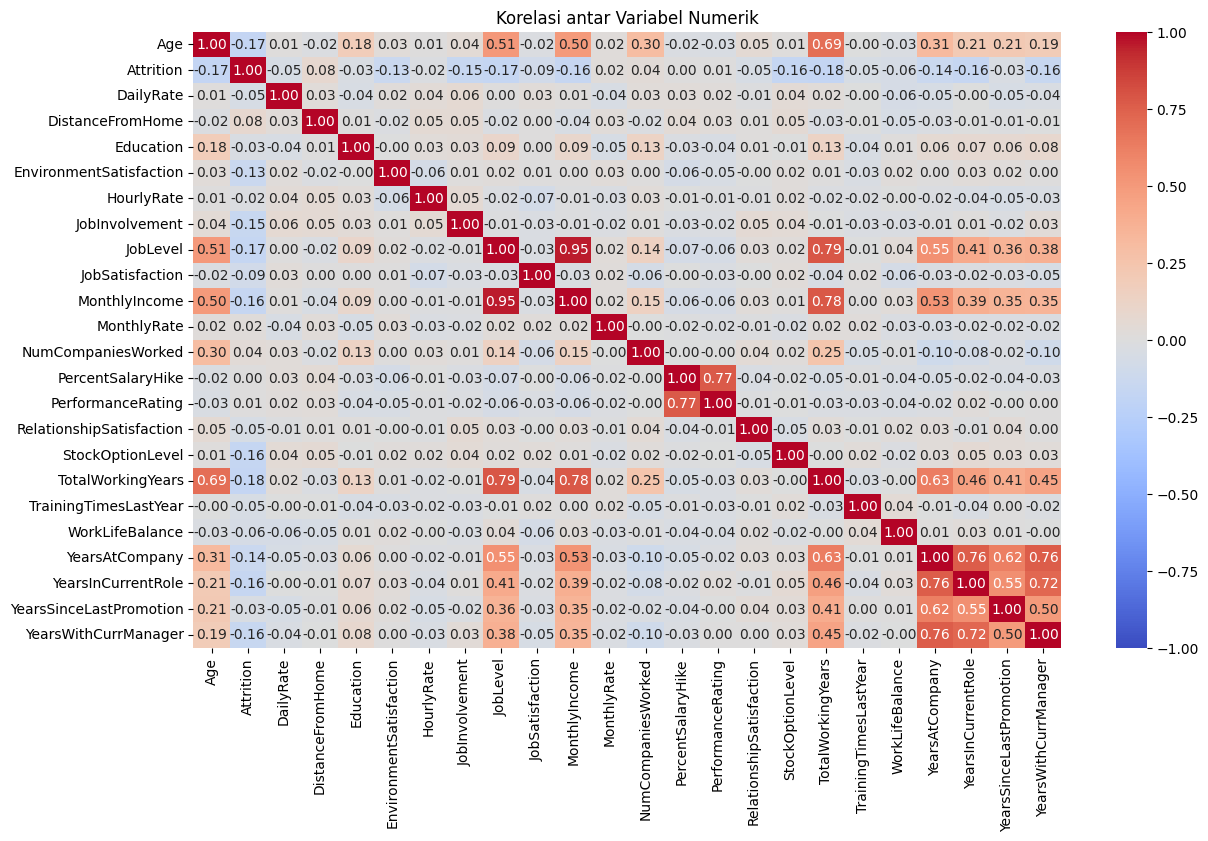

In [138]:
numeric_cols = df.select_dtypes(include=['number']).columns
correlation = df[numeric_cols].corr()
plt.figure(figsize=(14, 8))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt='.2f',
               vmin=-1,
               vmax=1)
plt.title('Korelasi antar Variabel Numerik')
plt.show()

**Korelasi Numerik terhadap Attrition**

In [139]:
corr = df.corr(numeric_only=True)['Attrition'].sort_values(ascending=False)
corr

,Attrition
Attrition,1.000000
DistanceFromHome,0.078074
NumCompaniesWorked,0.037429
MonthlyRate,0.023299
PerformanceRating,0.007755
PercentSalaryHike,0.004907
HourlyRate,-0.017524
YearsSinceLastPromotion,-0.031944
Education,-0.032631
TrainingTimesLastYear,-0.047859


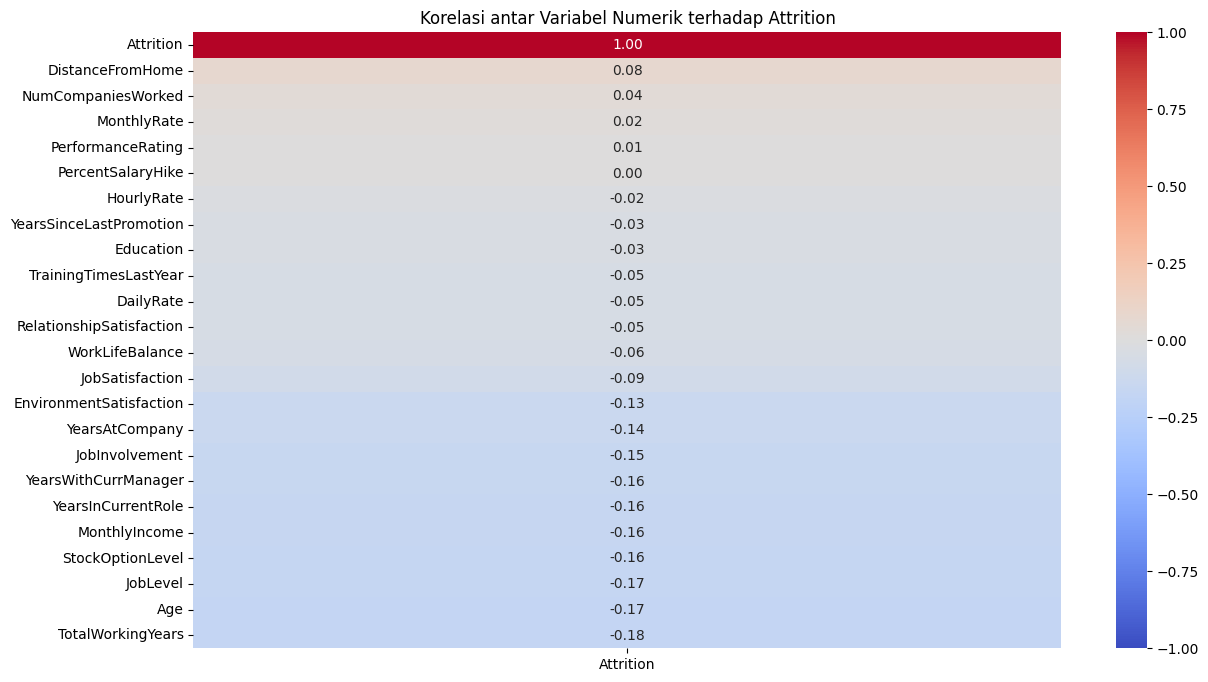

In [140]:
numeric_cols = df.select_dtypes(include=['number']).columns
correlation_attrition = df[numeric_cols].corr()
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_attrition['Attrition'].sort_values(ascending=False).to_frame(),
               annot=True,
               cmap='coolwarm',
               fmt='.2f',
               vmin=-1,
               vmax=1)
plt.title('Korelasi antar Variabel Numerik terhadap Attrition')
plt.show()


**Insight:**
- Korelasi Positif
  - Semakin jauh jarak rumah ke kantor (DistanceFromHome: 0,08), semakin tinggi kemungkinan Attrition
  - Karyawan yang memiliki riwayat sering pindah perusahaan cenderung melakukan hal yang sama lagi (NumCompaniesWorked: 0,04)
- Korelasi Negatif
  - Semakin lama total bekerja (TotalWorkingYears: -0,18), semakin kecil kemungkinan Attrition
  - Karyawan yang lebih muda (Age: -0,17) dan berada di level jabatan rendah (JobLevel: -0,17) cenderung memiliki kemungkinan Attrition yang tinggi
- Tidak Signifikan
  - Kenaikan gaji tahunan (PercentSalaryHike: 0,00) dan Rating kinerja (PerformanceRating: 0,01) tidak berpengaruh signifikan


**High Risk Attrition**

In [141]:
high_risk = df[df['Attrition'] == 1]
low_risk = df[df['Attrition'] == 0]

comparison = pd.DataFrame({
    'High Risk': high_risk.mean(numeric_only=True),
    'Low Risk': low_risk.mean(numeric_only=True)
})

comparison['Difference'] = comparison['High Risk'] - comparison['Low Risk']
comparison.sort_values(by='Difference', ascending=False).head(10)

,High Risk,Low Risk,Difference
MonthlyRate,14631.011173,14193.211604,437.799569
DistanceFromHome,10.368715,8.695108,1.673607
Attrition,1.000000,0.000000,1.000000
NumCompaniesWorked,2.916201,2.664391,0.251810
PercentSalaryHike,15.195531,15.147895,0.047635
PerformanceRating,3.156425,3.149033,0.007392
Education,2.804469,2.894198,-0.089729
WorkLifeBalance,2.670391,2.782708,-0.112317
RelationshipSatisfaction,2.597765,2.753129,-0.155363
TrainingTimesLastYear,2.631285,2.797497,-0.166212


**Insight:**
- Kelompok High Risk cenderung
  - Memiliki rata-rata MonthlyRate yang lebih tinggi.
  - Tinggal lebih jauh dari kantor
  - Sering pindah kerja
  - Pelatihan lebih sedikit (TrainingTimesLastYear)
  - Kepuasan hubungan (RelationshipSatisfaction) dan keseimbangan hidup (WorkLifeBalance) yang lebih rendah
- Perbedaan Tipis
  - PercentSalaryHike dan PerformanceRating memiliki selisih mendekati 0. Hal ini menunjukkan bahwa kenaikan gaji dan rating kinerja bukan faktor pembeda antara keluar atau bertahan.

## Data Preparation / Preprocessing


**Data Encoding**

In [142]:
df_fe=df.copy()

df_fe = pd.get_dummies(df_fe, columns=category_cols, drop_first=True)
df_fe = df_fe.astype('int64')
df_fe.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1,37,1,1141,11,2,1,61,1,2,2,...,0,0,0,0,0,0,0,1,0,0
2,51,1,1323,4,4,1,34,3,1,3,...,0,0,0,0,1,0,0,1,0,1
3,42,0,555,26,3,3,77,3,4,2,...,0,0,0,0,0,1,0,1,0,0
6,40,0,1124,1,2,2,57,1,2,4,...,0,0,0,0,0,1,0,1,0,1
7,55,1,725,2,3,4,78,3,5,1,...,0,1,0,0,0,0,0,1,0,1


**Data Splitting**

In [143]:
X = df_fe.drop('Attrition', axis=1)
y = df_fe['Attrition']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('Jumlah data total: ',len(X))
print('Jumlah data latih: ',len(X_train))
print('Jumlah data test: ',len(X_test))

Jumlah data total:  1058
Jumlah data latih:  846
Jumlah data test:  212


**Data Scaling**

In [144]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**SMOTE**

In [145]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train,y_train)
print('Sebelum SMOTE:', Counter(y_train))
print('Sesudah SMOTE:', Counter(y_train_res))

Sebelum SMOTE: Counter({0: 706, 1: 140})
Sesudah SMOTE: Counter({0: 706, 1: 706})


## EDA Lanjutan

**Korelasi Numerik terhadap Attrition**

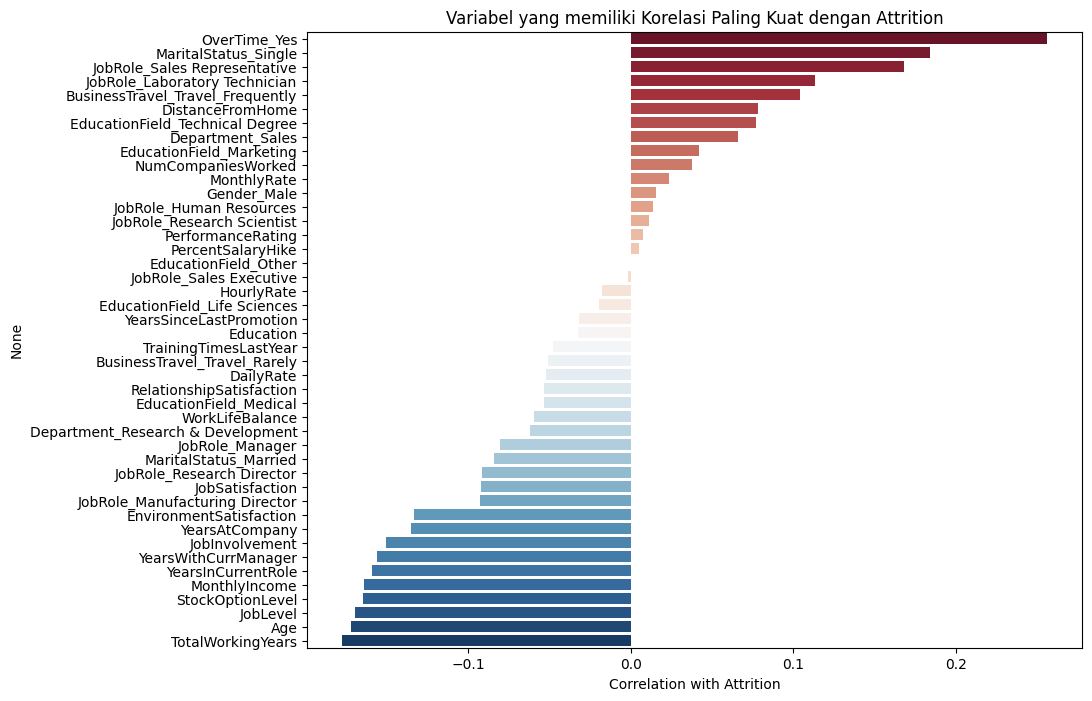

In [146]:
correlation2=df_fe.corr()

attrition_correlation=correlation2['Attrition'].sort_values(ascending=False)

factors= attrition_correlation
factors=factors.drop('Attrition')

factors

plt.figure(figsize=(10,8))
sns.barplot(x=factors.values, y= factors.index, hue=factors.index, dodge=False, palette='RdBu', legend=False)
plt.title('Variabel yang memiliki Korelasi Paling Kuat dengan Attrition')
plt.xlabel('Correlation with Attrition')
plt.show()

**Insight:**
- Meningkatkan Attrition
  - OverTime_Yes (0,256)
  - MaritalSatus_Single (0,184)
  - JobRole tertentu (Sales Representative, Laboratory Technical)
  - BusinessTravel_Frequently
  - DistanceFromHome
- Menurunkan Attrition
  - TotalWorkingYears
  - Age
  - JobLevel
  - MonthlyIncome
  - StockOptionLevel
  - YearsInCurrentRole
  - YearsInCurrManager


## Modeling

In [147]:
models={'Logistic Regression': LogisticRegression(max_iter=1000),
       'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
       'Gradient Boosting': GradientBoostingClassifier(random_state=42),
       'XG Boost': XGBClassifier(random_state=42, eval_metric='logloss')}

## Evaluation

ROC AUC: 0.8532681191640729
Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.67      0.79       173
           1       0.37      0.85      0.51        39

    accuracy                           0.70       212
   macro avg       0.66      0.76      0.65       212
weighted avg       0.84      0.70      0.74       212



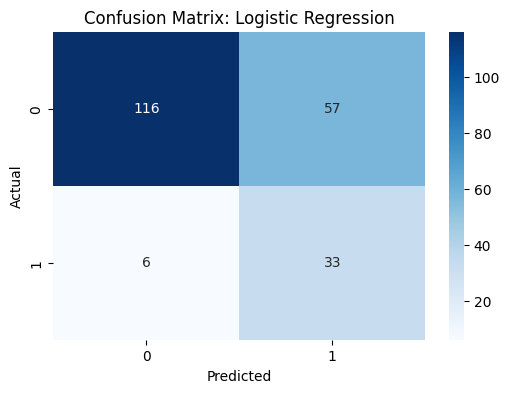

ROC AUC: 0.7948717948717948
Model: Random Forest
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       173
           1       0.48      0.67      0.56        39

    accuracy                           0.81       212
   macro avg       0.70      0.75      0.72       212
weighted avg       0.84      0.81      0.82       212



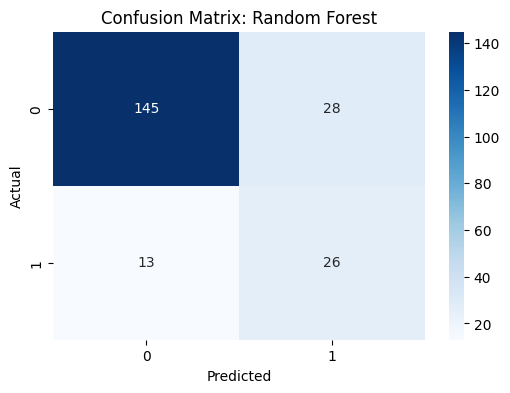

ROC AUC: 0.8261449533125833
Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       173
           1       0.60      0.62      0.61        39

    accuracy                           0.85       212
   macro avg       0.76      0.76      0.76       212
weighted avg       0.86      0.85      0.85       212



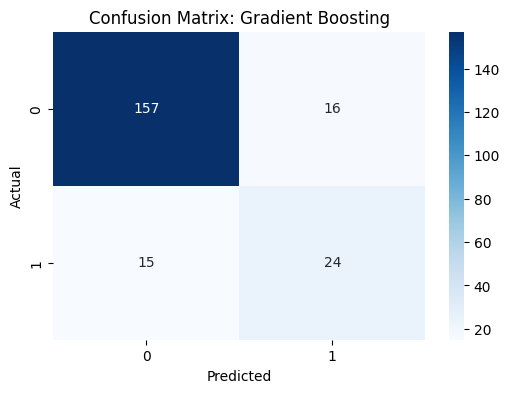

ROC AUC: 0.7969467911664445
Model: XG Boost
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       173
           1       0.71      0.51      0.60        39

    accuracy                           0.87       212
   macro avg       0.81      0.73      0.76       212
weighted avg       0.86      0.87      0.86       212



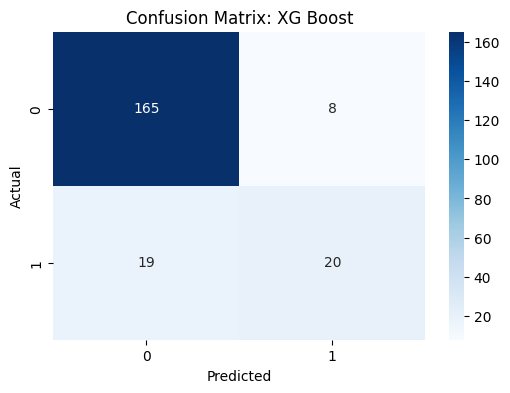

In [148]:
results = []
for name, model in models.items():
    model.fit(X_train_res, y_train_res)

    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.3).astype(int)

    auc = roc_auc_score(y_test, y_prob)
    print('ROC AUC:', auc)

    results.append((name, auc))

    print(f'Model: {name}')
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

**Insight:**
- Model terbaik adalah Logistic Regression

**Menyimpan Model Terbaik**

In [149]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_res, y_train_res)

joblib.dump(best_model, 'best_model.pkl')

['best_model.pkl']

## Feature Importance

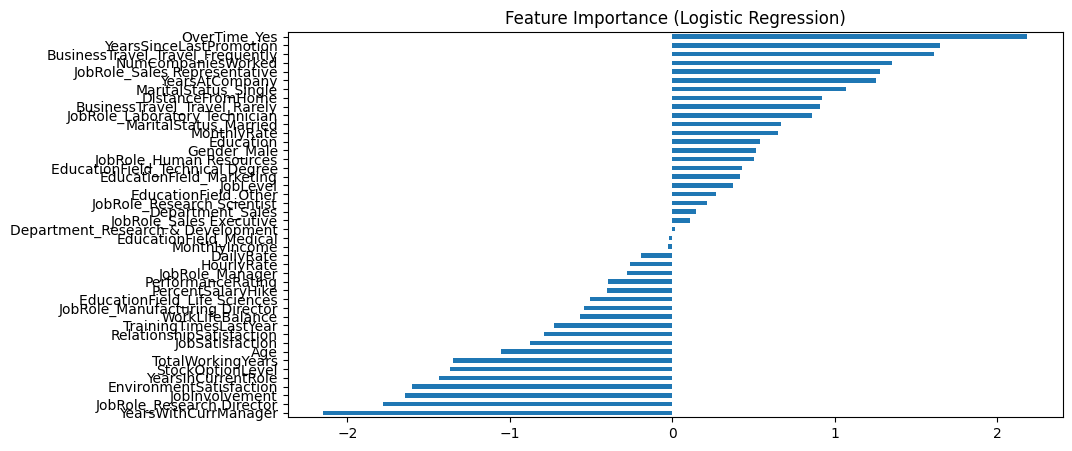

,0
YearsWithCurrManager,-2.150804
JobRole_Research Director,-1.777934
JobInvolvement,-1.645001
EnvironmentSatisfaction,-1.601700
YearsInCurrentRole,-1.438029
StockOptionLevel,-1.367278
TotalWorkingYears,-1.352079
Age,-1.051504
JobSatisfaction,-0.876884
RelationshipSatisfaction,-0.790712


In [150]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

importance = pd.Series(lr.coef_[0], index=X.columns)
importance = importance.sort_values()

plt.figure(figsize=(10,5))
importance.plot(kind='barh')
plt.title('Feature Importance (Logistic Regression)')
plt.show()

importance

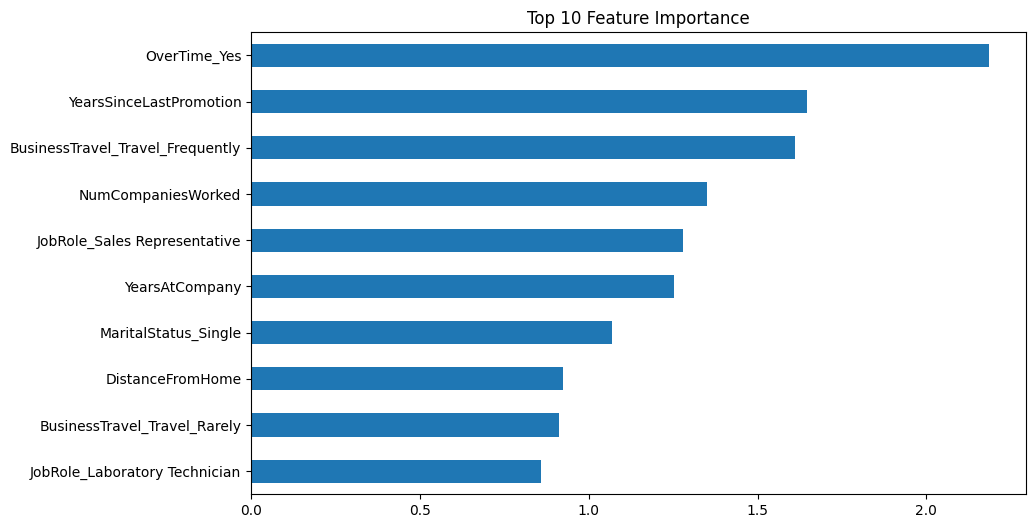

,0
OverTime_Yes,2.186049
YearsSinceLastPromotion,1.647853
BusinessTravel_Travel_Frequently,1.611612
NumCompaniesWorked,1.350650
JobRole_Sales Representative,1.278255
YearsAtCompany,1.253506
MaritalStatus_Single,1.070192
DistanceFromHome,0.922625
BusinessTravel_Travel_Rarely,0.912101
JobRole_Laboratory Technician,0.859482


In [151]:
lr_top = LogisticRegression(random_state=42, max_iter=2000) # Increased max_iter
lr_top.fit(X_train_res, y_train_res)

importance_top = pd.Series(lr_top.coef_[0], index=X.columns)
importance_top = importance_top.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance_top.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importance')
plt.gca().invert_yaxis()
plt.show()

importance_top.head(10)

**Insight:**
- Faktor yang meningkatkan Attrition
  - Overtime tinggi
  - Lama tidak promosi
  - Sering melakukan business travel
- Faktor yang menurunkan Attrition
  - Lama bekerja dengan manager yang sama
  - Job Involvement tinggi
  - Kepuasan lingkungan kerja tinggi

### Conclusion

1. Faktor-Faktor Penyebab Attrition
    - Faktor Pekerjaan
      - Karyawan yang lembur memiliki risiko keluar paling tinggi
      - Job role terteentu memiliki Attrition lebih tinggi
      - Frekuensi business travel juga meningkatkan risiko
    - Faktor Karier & Kompensasi
      - Karyawan dengan Job Level, gaji, dan stock option yang rendah lebih rentan keluar
    - Faktor Pengalaman Kerja
      - Karyawan dengan masa kerja dan lama kerja dengan manager rendah lebih mudah keluar
    - Faktor Psikologis
      - Kepuasan kerja, lingkungan, relasi, dan work life balance yang rendah meningkatkan attrition

2. Perbedaan Attrition berdasarkan JobLevel
    - JobLevel 1 memiliki attrition tertinggi
    - Semakin tinggi level jabatan maka attrition semakin rendah, sehingga Entry-level employees paling rentan keluar

3. Pola karyawan high-risk untuk keluar:
    - Usia muda
    - Belum menikah
    - Job level rendah
    - Gaji lebih rendah
    - Sering lembur
    - Jarak rumah jauh
    - Sering pindah kerja sebelumnya
    - Masa kerja pendek
    - Kepuasan kerja dan work life balance rendah

4. Model Terbaik

   Model terbaik yang digunakan adalah Logistic Regression, dengan metrik performa sebagai berikut:
    - ROC AUC: 0.85
    - Accuracy: 0,70
    - Precision: 0,37
    - Recall: 0,85
    - F1-Score: 0,51

   Hal ini menunjukkan bahwa model mampu mengidentifikasi sebagian besar kasus attrition, yang sangat penting dalam konteks bisnis untuk melakukan tindakan pencegahan lebih awal.

5. Rekomendasi untuk Perusahaan
    - Kurangi overtime
    - perbaiki work life balance
    - Fokus retensi di karyawan baru
    - Perjelas jalur karier dan promosi
